In [2]:
import ROOT
from collections import Counter
import pdg 
import numpy as np
import pandas as pd
api = pdg.connect()

In [87]:
file_path = "outputs/lnu_background_no_lepton_veto/p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu/chunk_0.root"
file = ROOT.TFile.Open(file_path)
tree = file.Get("events")   # events is TTree name

In [88]:
def pdg_name(pdg_ids):
    """Return PDG particle names using the PDG API.
       Works for single IDs or lists/arrays of IDs."""
    
    # Helper to look up a single ID
    def lookup(pid):
        # skip invalid PDG codes (0, None, NaN)
        if pid == 0:  
            return 0

        try:
            particle = api.get_particle_by_mcid(int(pid))
            return particle.name if particle else str(int(pid))
        except Exception:
            return str(int(pid))

    # Handle single value or iterable
    if isinstance(pdg_ids, (list, tuple, set)):
        return [lookup(pid) for pid in pdg_ids]
    else:
        return lookup(pdg_ids)

In [89]:
def flatten(xss):
    #flatten arbitrarily nested list
    flat_list = []
    for item in xss:
        if isinstance(item, (list, tuple)):
            flat_list.extend(flatten(item))
        else:
            flat_list.append(item)
    return flat_list

In [90]:
def map_nested(func, data):
    """Recursively apply func to every non-list element in arbitrarily nested lists."""
    if isinstance(data, (list, tuple)):
        return [map_nested(func, x) for x in data]
    else:
        return func(data)

In [91]:
def not_empty(x):
    """Return True if there's any non-empty element in nested list/tuple."""
    if isinstance(x, (list, tuple)):
        return any(not_empty(i) for i in x)
    else:
        return x is not None

In [92]:
n_events = tree.GetEntries()
print(n_events)


92510


In [93]:
def calc_cos_theta(px,py,pz,p_tot,utx,uty,utz):
    cosTheta = (px*utx+py*uty+pz*utz)/p_tot
    return cosTheta


In [98]:
def build_decay_tree(event):

   decay_chain = []
   decay_chain_hemis_sgn = []
   hemisEmin_particles =[]
   hemisEmax_particles=[]
   hemisEmin_particles_fs=[]
   particles = len(event.MC_PDG)
   

   for p in range(particles):

      ID = event.MC_PDG[p]
      d1 = event.MC_D1[p]
      d2 = event.MC_D2[p]

      px = event.MC_px[p]
      py = event.MC_py[p]
      pz = event.MC_pz[p]
      p_tot = event.MC_p[p]

      unitThrust_x = event.EVT_unitThrust_x
      unitThrust_y = event.EVT_unitThrust_y
      unitThrust_z = event.EVT_unitThrust_z

      cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

      if cosTheta>0: #ie. in hemisEmin
         hemisEmin_particles.append(p)
         if abs(ID)==5: # start with b quark
            #print(f"b or b bar in hemisEmin index: {p}")
            D1_index = event.MC_D1[p]
            D2_index = event.MC_D2[p]
            D1_ID = event.MC_PDG[D1_index]
            if D2_index>=0:
               D2_ID = event.MC_PDG[D2_index]
            else:
               D2_ID = -999

            decay = [[ID]]  
            hemis_sgn = [[np.sign(cosTheta)]] #+1 for Emin, -1 gfor Emax                 
            
            
            while abs(D1_ID)==5:
               p = D1_index

               px = event.MC_px[p]
               py = event.MC_py[p]
               pz = event.MC_pz[p]
               p_tot = event.MC_p[p]

               D1_index = event.MC_D1[p]
               D2_index = event.MC_D2[p]

               D1_ID = event.MC_PDG[D1_index]

               if D2_index>=0:
                  D2_ID = event.MC_PDG[D2_index]
                  D2_px = event.MC_px[D2_index]
                  D2_py = event.MC_py[D2_index]
                  D2_pz = event.MC_pz[D2_index]
                  D2_p_tot = event.MC_p[D2_index]
                  D2_costheta = calc_cos_theta(D2_px,D2_py,D2_pz,D2_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)
               else:
                  D2_ID = -999
                  D2_costheta = 0
       

               D1_px = event.MC_px[D1_index]
               D1_py = event.MC_py[D1_index]
               D1_pz = event.MC_pz[D1_index]
               D1_p_tot = event.MC_p[D1_index]

               

               D1_costheta = calc_cos_theta(D1_px,D1_py,D1_pz,D1_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)
               


            if abs(D1_ID)!=5: #ie. if daughter isn't a bquark - start with b  hadronidsation 
               decay.append([ID])
               print((180/3.141592653589793)*(np.arccos(D1_costheta)))

               m_costheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

               hemis_sgn.append([np.sign(m_costheta)]) #+1 for Emin, -1 gfor Emax

               if D1_index == D2_index:
                  daughter_IDs = [D1_ID]
                  daughter_indices = [D1_index]
                  daughter_hemis_sgns = [np.sign(D1_costheta)]
               else:
                  daughter_IDs = [D1_ID,D2_ID]
                  daughter_indices = [D1_index,D2_index]
                  daughter_hemis_sgns = [np.sign(D1_costheta), np.sign(D2_costheta)]
                  #print(daughter_indices)
                  
               decay.append(daughter_IDs)
               hemis_sgn.append(daughter_hemis_sgns)

               while any(x != -999 for x in daughter_indices): 
                     
                  gd_IDs = []
                  gd_indices = []
                  gd_hemis_sgns = []

                  for d in dict.fromkeys(daughter_indices): # ie. only does for unique daighters
                     if d>0:
                        d_D1_index = event.MC_D1[d]
                        d_D2_index = event.MC_D2[d]


                        if d_D1_index>=0:
                           d_D1_ID = event.MC_PDG[d_D1_index]
                           d_D1_px = event.MC_px[d_D1_index]
                           d_D1_py = event.MC_py[d_D1_index]
                           d_D1_pz = event.MC_pz[d_D1_index]
                           d_D1_p_tot = event.MC_p[d_D1_index]
                           d_D1_costheta = calc_cos_theta(d_D1_px,d_D1_py,d_D1_pz,d_D1_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

                        else: 
                           d_D1_ID = -999
                           d_D1_costheta = 0
                           
                        if d_D2_index>=0:
                           d_D2_ID = event.MC_PDG[d_D2_index]
                           d_D2_px = event.MC_px[d_D2_index]
                           d_D2_py = event.MC_py[d_D2_index]
                           d_D2_pz = event.MC_pz[d_D2_index]
                           d_D2_p_tot = event.MC_p[d_D2_index]
                           d_D2_costheta = calc_cos_theta(d_D2_px,d_D2_py,d_D2_pz,d_D2_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

                        else: 
                           d_D2_ID = -999
                           d_D2_costheta = 0

                        d_D_IDs = [d_D1_ID,d_D2_ID]
                        d_D_indices = [d_D1_index,d_D2_index]
                        d_D_hemis_sgns = [np.sign(d_D1_costheta),np.sign(d_D2_costheta)]

                     else:
                        d_D_IDs = [-999,-999]
                        d_D_indices = [-999,-999]
                        d_D_hemis_sgns = [0,0]

                     gd_IDs.extend(d_D_IDs)
                     gd_indices.extend(d_D_indices)
                     gd_hemis_sgns.extend(d_D_hemis_sgns)

                  daughter_IDs = gd_IDs
                  daughter_indices = gd_indices
                  daughter_hemis_sgns = gd_hemis_sgns

                  if any(x != -999 for x in gd_IDs):
                     decay.append(gd_IDs)
                     hemis_sgn.append(daughter_hemis_sgns)

               decay_chain.extend(decay)
               decay_chain_hemis_sgn.extend(hemis_sgn)
            break

               
   # Convert PDG codes to particle names
   named_decay = [pdg_name(x) for x in decay_chain]
   print(f"SS B decay chain: {named_decay}")
   print(f"hemis sgn for decay chain:{decay_chain_hemis_sgn}")

   #compare with reco info
   SS_fs = []
   OS_fs = []
   for k in range(len(event.Rec_in_hemisEmin)):
         particle = api.get_particle_by_mcid(event.Rec_true_PDG[k])
         if event.Rec_in_hemisEmin[k] ==1:
            SS_fs.append(particle.name)
         else:
            OS_fs.append(particle.name)

   #print(f"SS reco final states:{SS_fs}")
   #print(f"OS reco final states:{OS_fs}")

   fs_particles = len(event.MCfinal_PDG)
   fs_SS_particles = []
   for fs_p in range(fs_particles):

      ID = event.MCfinal_PDG[fs_p]

      px = event.MCfinal_px[fs_p]
      py = event.MCfinal_py[fs_p]
      pz = event.MCfinal_pz[fs_p]
      p_tot = event.MCfinal_p[fs_p]

      unitThrust_x = event.EVT_unitThrust_x
      unitThrust_y = event.EVT_unitThrust_y
      unitThrust_z = event.EVT_unitThrust_z

      cosTheta = (px*unitThrust_x+py*unitThrust_y+pz*unitThrust_z)/p_tot

      if cosTheta>0: #ie. in hemisEmin
         particle = api.get_particle_by_mcid(ID)
         fs_SS_particles.append(particle.name)
   
   #print(f"SS MC final states:{fs_SS_particles}")


   # Count multiplicities
   reco_counts = Counter(SS_fs)
   mc_counts = Counter(fs_SS_particles)

   # Missed particles (in MC but not in reco)
   missed_counts = mc_counts - reco_counts
   missed_particles = list(missed_counts.elements())

   print(f"Missed particles in reco: {missed_particles}")

   # find reason for passing veto (based on four criteria)
   
   #1 tau decay to muon not on SS
   if not any(str(particle) in ['mu+', 'mu-'] for particle in flatten(named_decay)): #need str(particle) so that it doesn't complain for -99 float entreis
      reason = '1. No mu in SS decay chain'

   #2 muon missed (ie. in missing oarticle list - in true MC but not reco)
   elif any(str(particle) in ['mu+', 'mu-'] for particle in missed_particles):
      reason = "2. mu missed by reco"

   #3 muon reco on wrong side - ie. in OS_reco_fs and not SS_reco_fs
   elif any(str(particle) in ['mu+', 'mu-']  for particle in OS_fs if particle not in SS_fs):
         reason = "3. mu reconstructed on OS"
         mu_indices = [i for i, p in enumerate(flatten(named_decay)) if str(p) in ("mu+", "mu-")]

         if flatten(decay_chain_hemis_sgn)[mu_indices[0]] ==-1:
            reason += " AND true mu has OS mometum pointing"

   #4 muon decays in flight
   elif not any(str(particle) in ['mu+', 'mu-'] for particle in named_decay[-1]):
      reason = "4. mu decays in flight"
   
   else: 
      reason = "unknown"
      print(f"SS B decay chain: {named_decay}")
   
   print(reason)

   if named_decay ==[]:
      print(f"MCZ_pz:{event.MCZ_pz}")
      print(f"hemisEmin_e:{event.EVT_hemisEmin_e}")
      print(f"SS reco final states:{SS_fs}")
      print(f"OS reco final states:{OS_fs}")
      print(f"SS MC final states:{fs_SS_particles}")
            
   return {
        "decay_chain": decay_chain,
        "decay_chain_hemis_sgn":decay_chain_hemis_sgn,
        "named_decay": named_decay,
        "SS_reco_final_states": SS_fs,
        "OS_reco_final_states": OS_fs,
        "SS_MC_final_states": fs_SS_particles,
        "missed_particles": missed_particles,
        "reason_passed_veto":reason
    }


In [99]:
import csv
results = []
t = 0

for i, event in enumerate(tree):
    if event.EVT_hemisEmin_nLept != 0:
        continue  # skip events with leptons

    info = build_decay_tree(event)
    print("-----------------------------------------------------------") 
    results.append({
        "Event": i,
        "DecayChain": info["named_decay"],
        "DecayChain_hemis_sgn":info["decay_chain_hemis_sgn"],
        "SS_Reco_FS": info["SS_reco_final_states"],
        "OS_Reco_FS": info["OS_reco_final_states"],
        "SS_MC_FS": info["SS_MC_final_states"],
        "MissedParticles": info["missed_particles"],
        "Reason passed mu veto":info["reason_passed_veto"]
    })

    t += 1
    if t >= 15:
        break

# Save all to CSV
with open("decay_analysis_test.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)

print("CSV file 'decay_analysis.csv' created successfully!")


11.13939135389738
SS B decay chain: [['b'], ['b'], ['B-', 'p'], ['D^*(2007)0', 'K^*(892)-', '-999', '-999'], ['D0', 'pi0', 'Kbar0', 'pi-', '-999', '-999'], ['K-', 'pi+', 'gamma', 'gamma', 'K(S)0', '-999', '-999', '-999', '-999', '-999'], ['-999', '-999', '-999', '-999', '-999', '-999', '-999', '-999', 'pi+', 'pi-', '-999', '-999']]
hemis sgn for decay chain:[[1.0], [1.0], [1.0, 1.0], [1.0, 1.0, 0, 0], [1.0, 1.0, 1.0, 1.0, 0, 0], [1.0, 1.0, 1.0, 1.0, 1.0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 1.0, 1.0, 0, 0]]
Missed particles in reco: ['gamma', 'gamma', 'p']
1. No mu in SS decay chain
-----------------------------------------------------------
2.857679797191674
SS B decay chain: [['b'], ['b'], ['B^*-', 'rho(770)0'], ['B-', 'gamma', 'pi+', 'pi-'], ['tau-', 'nubar_tau', '-999', '-999', '-999', '-999', '-999', '-999'], ['nu_tau', 'mu-', '-999', '-999', '-999', '-999']]
hemis sgn for decay chain:[[1.0], [1.0], [1.0, 1.0], [1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 0, 0, 0, 0, 0, 0], [1.0, 1.0, 0, 

In [71]:
def build_decay_tree_Dgr2(event): #Note this doesn't include looking at hadronisation products

   decay_chain = []
   decay_chain_hemis_sgn = []
   hemisEmin_particles =[]
   hemisEmax_particles=[]
   hemisEmin_particles_fs=[]
   particles = len(event.MC_PDG)
   

   for p in range(particles):

      ID = event.MC_PDG[p]
      d1 = event.MC_D1[p]
      d2 = event.MC_D2[p]

      px = event.MC_px[p]
      py = event.MC_py[p]
      pz = event.MC_pz[p]
      p_tot = event.MC_p[p]

      unitThrust_x = event.EVT_unitThrust_x
      unitThrust_y = event.EVT_unitThrust_y
      unitThrust_z = event.EVT_unitThrust_z

      cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

      if cosTheta>0: #ie. in hemisEmin
         hemisEmin_particles.append(p)
         if abs(ID)==5: # start with b quark
            #print(f"b or b bar in hemisEmin index: {p}")
            D1_index = event.MC_D1[p]
            D2_index = event.MC_D2[p]

            D1_ID = event.MC_PDG[D1_index]
            D2_ID = event.MC_PDG[D2_index]  

            decay = [[ID]]  
            hemis_sgn = [[np.sign(cosTheta)]] #+1 for Emin, -1 gfor Emax                 
            
            
            while abs(D1_ID)==5:
               p = D1_index

               px = event.MC_px[p]
               py = event.MC_py[p]
               pz = event.MC_pz[p]
               p_tot = event.MC_p[p]

               D1_index = event.MC_D1[p]
               D2_index = event.MC_D2[p]

               D1_ID = event.MC_PDG[D1_index]
               D2_ID = event.MC_PDG[D2_index] 

               D1_px = event.MC_px[D1_index]
               D1_py = event.MC_py[D1_index]
               D1_pz = event.MC_pz[D1_index]
               D1_p_tot = event.MC_p[D1_index]

               D2_px = event.MC_px[D2_index]
               D2_py = event.MC_py[D2_index]
               D2_pz = event.MC_pz[D2_index]
               D2_p_tot = event.MC_p[D2_index]

               D1_costheta = calc_cos_theta(D1_px,D1_py,D1_pz,D1_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)
               D2_costheta = calc_cos_theta(D2_px,D2_py,D2_pz,D2_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)


            if abs(D1_ID)!=5: #ie. if daughter isn't a bquark - start with b  hadronidsation 
               decay.append([ID])
               m_costheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)
               hemis_sgn.append([np.sign(m_costheta)]) #+1 for Emin, -1 gfor Emax

               if D1_index == D2_index: # b meson
                  daughter_IDs = [D1_ID]
                  daughter_indices = [D1_index]
                  daughter_hemis_sgns = [np.sign(D1_costheta)]
               else:
                  daughter_IDs = [D1_ID,D2_ID]
                  daughter_indices = [D1_index,D2_index]
                  daughter_hemis_sgns = [np.sign(D1_costheta), np.sign(D2_costheta)]
                  #print(daughter_indices)
                  
               decay.append(daughter_IDs)
               hemis_sgn.append(daughter_hemis_sgns)

               while any(x != -999 for x in daughter_indices): 
                     
                  gd_IDs = []
                  gd_indices = []
                  gd_hemis_sgns = []

                  for d in dict.fromkeys(flatten(daughter_indices)): # ie. only does for unique daighters
                     if d>0:
                        d_D_IDs = []
                        d_D_indices = []
                        d_D_hemis_sgns = []
                        for k in range(particles):
                           if event.MC_M1[k] == d or event.MC_M2[k] == d: 
                              d_D_indices.append(k)  
                              d_D_IDs.append(event.MC_PDG[k])
                              d_D_px = event.MC_px[k]
                              d_D_py = event.MC_py[k]
                              d_D_pz = event.MC_pz[k]
                              d_D_p_tot = event.MC_p[k]
                              d_D_costheta = calc_cos_theta(d_D_px,d_D_py,d_D_pz,d_D_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)
                              d_D_hemis_sgns.append(np.sign(d_D_costheta))

                     gd_IDs.append(d_D_IDs)
                     gd_indices.append(d_D_indices)
                     gd_hemis_sgns.append(d_D_hemis_sgns)

                  daughter_IDs = gd_IDs
                  daughter_indices = gd_indices
                  daughter_hemis_sgns = gd_hemis_sgns

                  if not_empty(gd_IDs):
                     decay.append(gd_IDs)
                     hemis_sgn.append(daughter_hemis_sgns)

               decay_chain.extend(decay)
               decay_chain_hemis_sgn.extend(hemis_sgn)
            break

               
   # Convert PDG codes to particle names
   named_decay =  map_nested(pdg_name, decay_chain)
   print(f"SS B decay chain: {named_decay}")
   print(f"hemis sgn for decay chain:{decay_chain_hemis_sgn}")

   #compare with reco info
   SS_fs = []
   OS_fs = []
   for k in range(len(event.Rec_in_hemisEmin)):
         particle = api.get_particle_by_mcid(event.Rec_true_PDG[k])
         if event.Rec_in_hemisEmin[k] ==1:
            SS_fs.append(particle.name)
         else:
            OS_fs.append(particle.name)

   #print(f"SS reco final states:{SS_fs}")
   #print(f"OS reco final states:{OS_fs}")

   fs_particles = len(event.MCfinal_PDG)
   fs_SS_particles = []
   for fs_p in range(fs_particles):

      ID = event.MCfinal_PDG[fs_p]

      px = event.MCfinal_px[fs_p]
      py = event.MCfinal_py[fs_p]
      pz = event.MCfinal_pz[fs_p]
      p_tot = event.MCfinal_p[fs_p]

      unitThrust_x = event.EVT_unitThrust_x
      unitThrust_y = event.EVT_unitThrust_y
      unitThrust_z = event.EVT_unitThrust_z

      cosTheta = (px*unitThrust_x+py*unitThrust_y+pz*unitThrust_z)/p_tot

      if cosTheta>0: #ie. in hemisEmin
         particle = api.get_particle_by_mcid(ID)
         fs_SS_particles.append(particle.name)
   
   #print(f"SS MC final states:{fs_SS_particles}")


   # Count multiplicities
   reco_counts = Counter(SS_fs)
   mc_counts = Counter(fs_SS_particles)

   # Missed particles (in MC but not in reco)
   missed_counts = mc_counts - reco_counts
   missed_particles = list(missed_counts.elements())

   print(f"Missed particles in reco: {missed_particles}")

   # find reason for passing veto (based on four criteria)
   
   #1 tau decay to muon not on SS
   if not any(str(particle) in ['mu+', 'mu-'] for particle in flatten(named_decay)): #need str(particle) so that it doesn't complain for -99 float entreis
      reason = '1. No mu in SS decay chain'

   #2 muon missed (ie. in missing oarticle list - in true MC but not reco)
   elif any(str(particle) in ['mu+', 'mu-'] for particle in missed_particles):
      reason = "2. mu missed by reco"

   #3 muon reco on wrong side - ie. in OS_reco_fs and not SS_reco_fs
   elif any(str(particle) in ['mu+', 'mu-']  for particle in OS_fs if particle not in SS_fs):
         reason = "3. mu reconstructed on OS"
         mu_indices = [i for i, p in enumerate(flatten(named_decay)) if str(p) in ("mu+", "mu-")]

         if flatten(decay_chain_hemis_sgn)[mu_indices[0]] ==-1:
            reason += " AND true mu has OS mometum pointing"

   #4 muon decays in flight
   elif not any(str(particle) in ['mu+', 'mu-'] for particle in named_decay[-1]):
      reason = "4. mu decays in flight"
   
   else: 
      reason = "unknown"
      print(f"SS B decay chain: {named_decay}")
   
   print(reason)

   if named_decay ==[]:
      print(f"MCZ_pz:{event.MCZ_pz}")
      print(f"hemisEmin_e:{event.EVT_hemisEmin_e}")
      print(f"SS reco final states:{SS_fs}")
      print(f"OS reco final states:{OS_fs}")
      print(f"SS MC final states:{fs_SS_particles}")
            
   return {
        "decay_chain": decay_chain,
        "decay_chain_hemis_sgn":decay_chain_hemis_sgn,
        "named_decay": named_decay,
        "SS_reco_final_states": SS_fs,
        "OS_reco_final_states": OS_fs,
        "SS_MC_final_states": fs_SS_particles,
        "missed_particles": missed_particles,
        "reason_passed_veto":reason
    }

In [72]:
results = []
t = 0

for i, event in enumerate(tree):
    if event.EVT_hemisEmin_nLept != 0:
        continue  # skip events with leptons

    info = build_decay_tree_Dgr2(event)
    print("-----------------------------------------------------------") 
    results.append({
        "Event": i,
        "DecayChain": info["named_decay"],
        "DecayChain_hemis_sgn":info["decay_chain_hemis_sgn"],
        "SS_Reco_FS": info["SS_reco_final_states"],
        "OS_Reco_FS": info["OS_reco_final_states"],
        "SS_MC_FS": info["SS_MC_final_states"],
        "MissedParticles": info["missed_particles"],
        "Reason passed mu veto":info["reason_passed_veto"]
    })

    t += 1
    if t >= 15:
        break

SS B decay chain: [['b'], ['b'], ['B-'], [['D^*(2007)0', 'K^*(892)-', 'K0']], [['D0', 'pi0'], ['Kbar0', 'pi-'], ['K(L)0']], [['K-', 'pi+', 'pi0'], ['gamma', 'gamma'], ['K(S)0'], [], []], [[], [], ['gamma', 'gamma'], [], [], ['pi+', 'pi-']]]
hemis sgn for decay chain:[[1.0], [1.0], [1.0], [[1.0, 1.0, 1.0]], [[1.0, 1.0], [1.0, 1.0], [1.0]], [[1.0, 1.0, 1.0], [1.0, 1.0], [1.0], [], []], [[], [], [1.0, 1.0], [], [], [1.0, 1.0]]]
Missed particles in reco: ['gamma', 'gamma', 'p']
1. No mu in SS decay chain
-----------------------------------------------------------
SS B decay chain: [['b'], ['b'], ['B^*-'], [['B-', 'gamma']], [['tau-', 'nubar_tau'], []], [['nu_tau', 'mu-', 'nubar_mu'], []]]
hemis sgn for decay chain:[[1.0], [1.0], [1.0], [[1.0, 1.0]], [[1.0, 1.0], []], [[1.0, 1.0, 1.0], []]]
Missed particles in reco: ['gamma', 'gamma', 'pi+', 'pi-', 'nubar_tau', 'nu_tau', 'mu-', 'nubar_mu']
2. mu missed by reco
-----------------------------------------------------------
SS B decay chain: [['

### Study csv output from script

In [4]:
csv_path = "decay_analysis.csv"

csv = pd.read_csv(csv_path)

In [5]:
fraction_true = (csv['FunkyHaronisation_flag'] == True).mean()
fraction_true

0.7305776892430279

### Thrust - b (and B) plots

#### Pass lepton veto

/tmp/ipykernel_409623/1661690491.py:20: RuntimeWarning: invalid value encountered in arccos
  angle = (180/3.141592653589793)*(np.arccos((unitThrust_x * MCq1_px + unitThrust_y * MCq1_py + unitThrust_z * MCq1_pz) / np.sqrt( (MCq1_px**2 + MCq1_py**2 + MCq1_pz**2))))


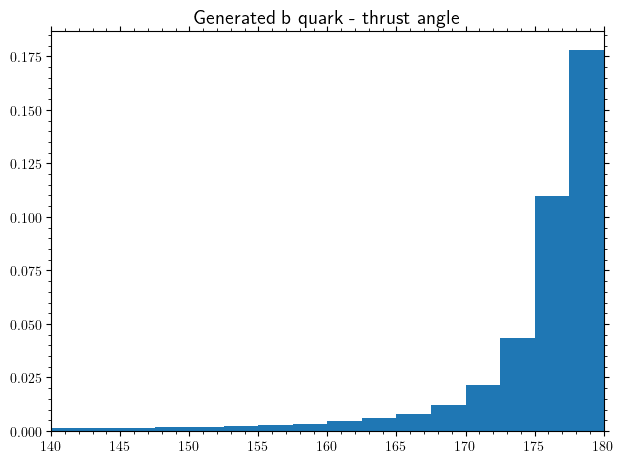

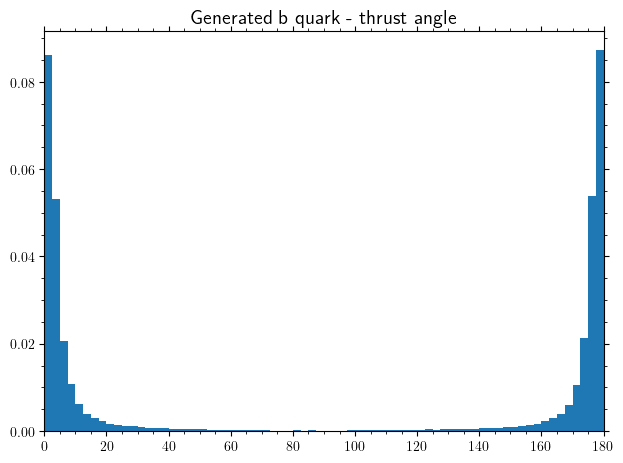

In [54]:
import matplotlib.pyplot as plt

angles = []

for i, event in enumerate(tree):
    if event.EVT_hemisEmin_nLept != 0:

        MCq1_px = event.MCq1_px
        MCq1_py = event.MCq1_py
        MCq1_pz = event.MCq1_pz

        MCq2_px = event.MCq2_px
        MCq2_py = event.MCq2_py
        MCq2_pz = event.MCq2_pz

        unitThrust_x = event.EVT_unitThrust_x
        unitThrust_y = event.EVT_unitThrust_y
        unitThrust_z = event.EVT_unitThrust_z

        angle = (180/3.141592653589793)*(np.arccos((unitThrust_x * MCq1_px + unitThrust_y * MCq1_py + unitThrust_z * MCq1_pz) / np.sqrt( (MCq1_px**2 + MCq1_py**2 + MCq1_pz**2))))
        angles.append(angle)

plt.hist(angles,range=(140,180), bins=16, density=True)
plt.title("Generated b quark - thrust angle")
plt.show()

plt.hist(angles,range=(0,180), bins=72, density=True)
plt.title("Generated b quark - thrust angle")
plt.show()

In [52]:
angles = []
for i, event in enumerate(tree):   
   particles = len(event.MC_PDG)   
   for p in range(particles):

      ID = event.MC_PDG[p]
      d1 = event.MC_D1[p]
      d2 = event.MC_D2[p]

      px = event.MC_px[p]
      py = event.MC_py[p]
      pz = event.MC_pz[p]
      p_tot = event.MC_p[p]

      unitThrust_x = event.EVT_unitThrust_x
      unitThrust_y = event.EVT_unitThrust_y
      unitThrust_z = event.EVT_unitThrust_z

      cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

      if cosTheta>0: #ie. in hemisEmin
         if abs(ID)==5: # start with b quark
            #print(f"b or b bar in hemisEmin index: {p}")
            D1_index = event.MC_D1[p]
            D2_index = event.MC_D2[p]

            D1_ID = event.MC_PDG[D1_index]
            D2_ID = event.MC_PDG[D2_index]  

            
            while abs(D1_ID)==5:
               p = D1_index

               px = event.MC_px[p]
               py = event.MC_py[p]
               pz = event.MC_pz[p]
               p_tot = event.MC_p[p]

               D1_index = event.MC_D1[p]
               D2_index = event.MC_D2[p]

               D1_ID = event.MC_PDG[D1_index]
               D2_ID = event.MC_PDG[D2_index] 

               D1_px = event.MC_px[D1_index]
               D1_py = event.MC_py[D1_index]
               D1_pz = event.MC_pz[D1_index]
               D1_p_tot = event.MC_p[D1_index]

               D2_px = event.MC_px[D2_index]
               D2_py = event.MC_py[D2_index]
               D2_pz = event.MC_pz[D2_index]
               D2_p_tot = event.MC_p[D2_index]

               D1_costheta = calc_cos_theta(D1_px,D1_py,D1_pz,D1_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)
               D2_costheta = calc_cos_theta(D2_px,D2_py,D2_pz,D2_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)


            if abs(D1_ID)!=5: #ie. if daughter isn't a bquark - start with b  hadronidsation 
               angle = ((180/3.141592653589793)*(np.arccos(D1_costheta)))
               angles.append(angle)


/tmp/ipykernel_409623/2842851484.py:60: RuntimeWarning: invalid value encountered in arccos
  angle = ((180/3.141592653589793)*(np.arccos(D1_costheta)))


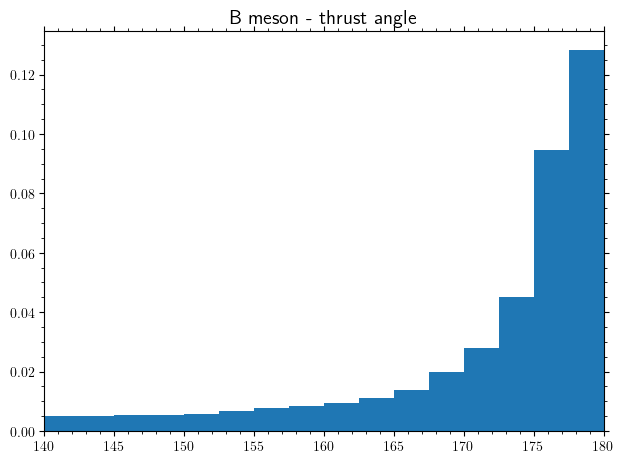

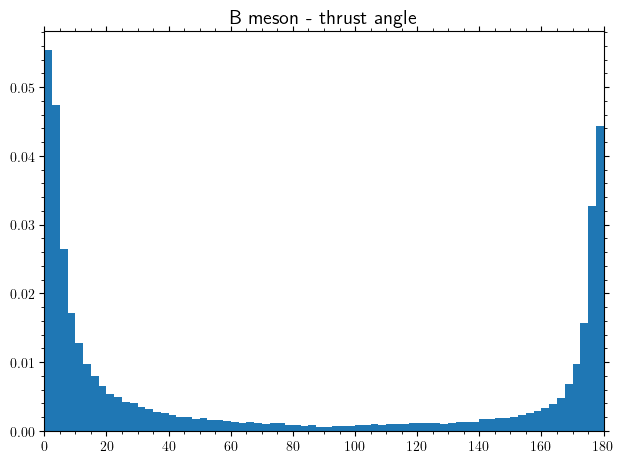

In [53]:
plt.hist(angles,range=(140,180), bins=16, density=True)
plt.title("B meson - thrust angle")
plt.show()

plt.hist(angles,range=(0,180), bins=72, density=True)
plt.title("B meson - thrust angle")
plt.show()



#### Fail lepton veto

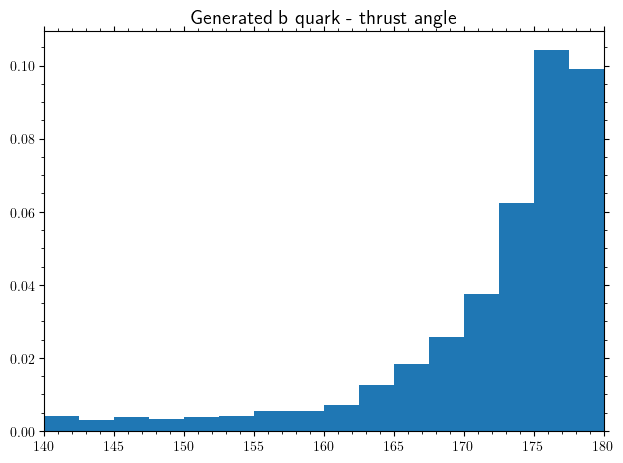

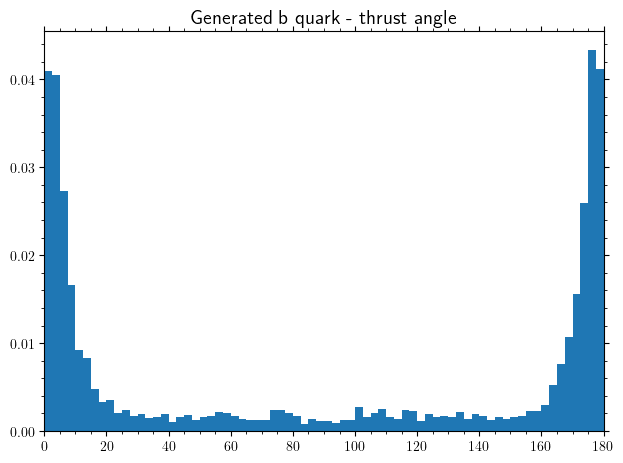

In [73]:
angles = []

for i, event in enumerate(tree):
    if event.EVT_hemisEmin_nLept == 0:

        MCq1_px = event.MCq1_px
        MCq1_py = event.MCq1_py
        MCq1_pz = event.MCq1_pz

        MCq2_px = event.MCq2_px
        MCq2_py = event.MCq2_py
        MCq2_pz = event.MCq2_pz

        unitThrust_x = event.EVT_unitThrust_x
        unitThrust_y = event.EVT_unitThrust_y
        unitThrust_z = event.EVT_unitThrust_z

        angle = (180/3.141592653589793)*(np.arccos((unitThrust_x * MCq1_px + unitThrust_y * MCq1_py + unitThrust_z * MCq1_pz) / np.sqrt( (MCq1_px**2 + MCq1_py**2 + MCq1_pz**2))))
        angles.append(angle)

plt.hist(angles,range=(140,180), bins=16, density=True)
plt.title("Generated b quark - thrust angle")
plt.show()

plt.hist(angles,range=(0,180), bins=72, density=True)
plt.title("Generated b quark - thrust angle")
plt.show()

In [74]:
angles = []
for i, event in enumerate(tree): 
   if event.EVT_hemisEmin_nLept == 0:  
      particles = len(event.MC_PDG)   
      for p in range(particles):

         ID = event.MC_PDG[p]
         d1 = event.MC_D1[p]
         d2 = event.MC_D2[p]

         px = event.MC_px[p]
         py = event.MC_py[p]
         pz = event.MC_pz[p]
         p_tot = event.MC_p[p]

         unitThrust_x = event.EVT_unitThrust_x
         unitThrust_y = event.EVT_unitThrust_y
         unitThrust_z = event.EVT_unitThrust_z

         cosTheta = calc_cos_theta(px,py,pz,p_tot,unitThrust_x,unitThrust_y,unitThrust_z)

         if cosTheta>0: #ie. in hemisEmin
            if abs(ID)==5: # start with b quark
               #print(f"b or b bar in hemisEmin index: {p}")
               D1_index = event.MC_D1[p]
               D2_index = event.MC_D2[p]

               D1_ID = event.MC_PDG[D1_index]
               D2_ID = event.MC_PDG[D2_index]  

               
               while abs(D1_ID)==5:
                  p = D1_index

                  px = event.MC_px[p]
                  py = event.MC_py[p]
                  pz = event.MC_pz[p]
                  p_tot = event.MC_p[p]

                  D1_index = event.MC_D1[p]
                  D2_index = event.MC_D2[p]

                  D1_ID = event.MC_PDG[D1_index]
                  D2_ID = event.MC_PDG[D2_index] 

                  D1_px = event.MC_px[D1_index]
                  D1_py = event.MC_py[D1_index]
                  D1_pz = event.MC_pz[D1_index]
                  D1_p_tot = event.MC_p[D1_index]

                  D2_px = event.MC_px[D2_index]
                  D2_py = event.MC_py[D2_index]
                  D2_pz = event.MC_pz[D2_index]
                  D2_p_tot = event.MC_p[D2_index]

                  D1_costheta = calc_cos_theta(D1_px,D1_py,D1_pz,D1_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)
                  D2_costheta = calc_cos_theta(D2_px,D2_py,D2_pz,D2_p_tot,unitThrust_x,unitThrust_y,unitThrust_z)


               if abs(D1_ID)!=5: #ie. if daughter isn't a bquark - start with b  hadronidsation 
                  angle = ((180/3.141592653589793)*(np.arccos(D1_costheta)))
                  angles.append(angle)


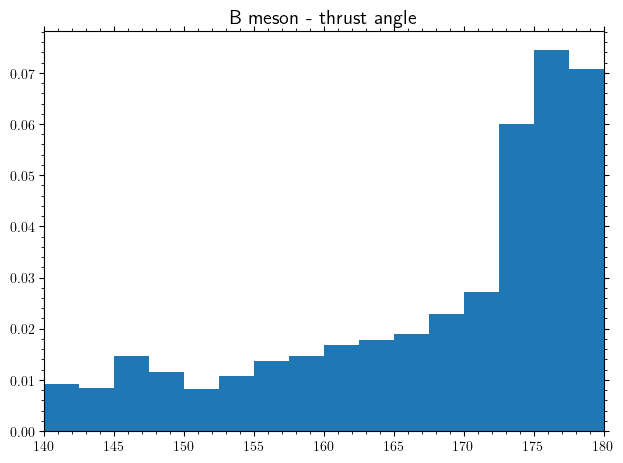

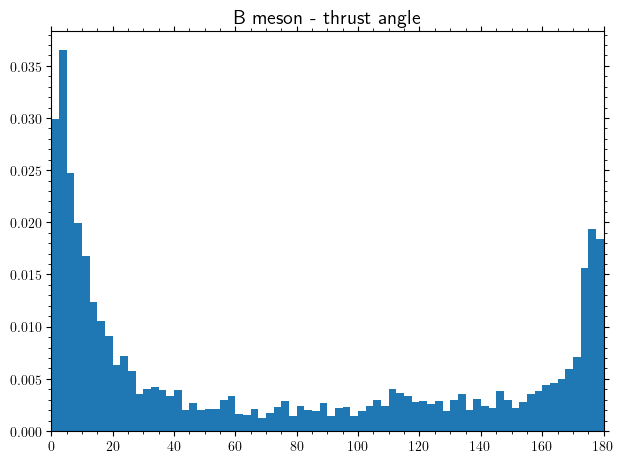

In [75]:
plt.hist(angles,range=(140,180), bins=16, density=True)
plt.title("B meson - thrust angle")
plt.show()

plt.hist(angles,range=(0,180), bins=72, density=True)
plt.title("B meson - thrust angle")
plt.show()

#### Note that even for event 237, initial quark (pre-hadronisation) fairly well aligned with thrust

In [45]:
for i, event in enumerate(tree):
    if i == 237:
        MCq1_px = event.MCq1_px
        MCq1_py = event.MCq1_py
        MCq1_pz = event.MCq1_pz

        MCq2_px = event.MCq2_px
        MCq2_py = event.MCq2_py
        MCq2_pz = event.MCq2_pz

        unitThrust_x = event.EVT_unitThrust_x
        unitThrust_y = event.EVT_unitThrust_y
        unitThrust_z = event.EVT_unitThrust_z

        angle = (180/3.141592653589793)*(np.arccos((unitThrust_x * MCq2_px + unitThrust_y * MCq2_py + unitThrust_z * MCq2_pz) / np.sqrt( (MCq2_px**2 + MCq2_py**2 + MCq2_pz**2))))
        print(angle)

157.36726092085786


### Quick Check that Thrust is pointing towards min hemisphere - OK.

In [46]:
def thrust_checker(event):

   Rec_hemisEmin_particles =[]
   particles = len(event.Rec_e)
   
   EVT_hemisEmin_esum=0
   EVT_hemisEmax_esum=0
   for p in range(particles):

      Rec_e = event.Rec_e[p]
      Rec_p = event.Rec_p[p]
      Rec_px = event.Rec_px[p]
      Rec_py = event.Rec_py[p]
      Rec_pz = event.Rec_pz[p]
      unitThrust_x = event.EVT_unitThrust_x
      unitThrust_y = event.EVT_unitThrust_y
      unitThrust_z = event.EVT_unitThrust_z

      cosTheta = (Rec_px*unitThrust_x+Rec_py*unitThrust_y+Rec_pz*unitThrust_z)/Rec_p

      if cosTheta>0: #ie. in hemisEmin
         Rec_hemisEmin_particles.append(p)
         EVT_hemisEmin_esum += Rec_e
      
      else:
         EVT_hemisEmax_esum += Rec_e

   EVT_hemisEmin_e_var = event.EVT_hemisEmin_e

   return EVT_hemisEmax_esum, EVT_hemisEmin_esum, EVT_hemisEmin_e_var

                     




In [58]:
t=0
for i, event in enumerate(tree):
    #print(event.EVT_hemisEmin_nLept)
    if event.EVT_hemisEmin_nLept == 0:
        EVT_hemisEmax_esum, EVT_hemisEmin_esum, EVT_hemisEmin_e_var= thrust_checker(event)
        if (EVT_hemisEmin_esum-EVT_hemisEmin_e_var)/EVT_hemisEmin_esum *10**2 < (EVT_hemisEmax_esum-EVT_hemisEmin_e_var)/EVT_hemisEmin_e_var:
            print("True")
        print(f"Emin_e_calc_error:{(EVT_hemisEmin_esum-EVT_hemisEmin_e_var)/EVT_hemisEmin_esum}")
        print(f"frac Emin_e Emax_e diff:{(EVT_hemisEmax_esum-EVT_hemisEmin_e_var)/EVT_hemisEmin_e_var}")
        print(f"Emin_e:{EVT_hemisEmin_esum}")
        print(f"Emax_e:{EVT_hemisEmax_esum}")
        print(f"MCZ_pz:{event.MCZ_pz}")
        build_decay_tree(event)
        print("-------------------------")
        t += 1
        if t >= 15:
            break

True
Emin_e_calc_error:1.067591185829664e-08
frac Emin_e Emax_e diff:0.12378947264718615
Emin_e:34.894352331757545
Emax_e:39.21390538662672
MCZ_pz:-5.899970574319013e-07
b
SS B decay chain: [['b'], ['B-'], ['D^*(2007)0', 'K^*(892)-'], ['D0', 'pi0', 'Kbar0', 'pi-'], ['K-', 'pi+', 'gamma', 'gamma', 'K(S)0', '-999', '-999', '-999'], ['-999', '-999', '-999', '-999', '-999', '-999', '-999', '-999', 'pi+', 'pi-', '-999', '-999']]
Missed particles in reco: ['gamma', 'gamma', 'p']
1. No mu in SS decay chain
-------------------------
True
Emin_e_calc_error:3.2257086744865226e-08
frac Emin_e Emax_e diff:6.068370585144432
Emin_e:6.929249987006187
Emax_e:48.978505205363035
MCZ_pz:0.0032006218098104
b
SS B decay chain: [['b'], ['B^*-'], ['B-', 'gamma'], ['tau-', 'nubar_tau', '-999', '-999'], ['nu_tau', 'mu-', '-999', '-999', '-999', '-999']]
Missed particles in reco: ['gamma', 'gamma', 'pi+', 'pi-', 'nubar_tau', 'nu_tau', 'mu-', 'nubar_mu']
2. mu missed by reco
-------------------------
True
Emin_e

### Energy Space

In [45]:
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt
import os
from glob import glob
import config as cfg
import pandas as pd

In [66]:
def get_list_of_files(folder,inputpath):
    
    path = os.path.join( inputpath, folder )
    if not os.path.exists( path ):
        raise RuntimeError( f"No such path {path}" )
    
    files = glob( os.path.join(inputpath, folder, "*.root") )
    if len(files)==0:
        raise RuntimeError( f"No root files found in {path}" )

    return files

def get_list_of_branches(folder,inputpath):
    f0 = get_list_of_files(folder,inputpath)[0]
    try:
        tr = uproot.open( f0+":events" )
        return [ br.name for br in tr.branches ]
    except:
        raise RuntimeError( f"No tree called events found in file {f0}" )

def as_array(folder, varname, cut, nchunks,inputpath):
     # if root files
    if len(glob(os.path.join(os.path.abspath(inputpath), folder, "*.root")))>0:
        if nchunks is not None:
            files = glob(os.path.join(os.path.abspath(inputpath), folder, "*.root"))[:nchunks]
            path = [ f"{f}:events" for f in files ]
        else:
            path = os.path.join( os.path.abspath(inputpath), folder, "*.root:events" )

        try: 
            #assuming vars of same shape use numpy
            arr = uproot.concatenate( path, expressions=varname, cut=cut, library="np") 
            print(type(arr))
        except:
            branches = get_list_of_branches(folder,inputpath)
            print( f"Branches found in files at path {folder}:" )
            for br in branches:
                print('  ', br)
            raise RuntimeError( f"Cannot process expression {varname} in files at path {folder}. Try combinations of branches from the list above." )
        
        df = pd.DataFrame(arr)
        

        return df

In [75]:
decay_list = ["p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"]
sample = "p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu"
varname = ["EVT_hemisEmin_e", "EVT_hemisEmax_e"]
cut = "EVT_hemisEmin_nLept==0"
inputpath = "outputs/lnu_background_no_lepton_veto/"

values = as_array(sample, varname, cut, None,inputpath) 

<class 'dict'>


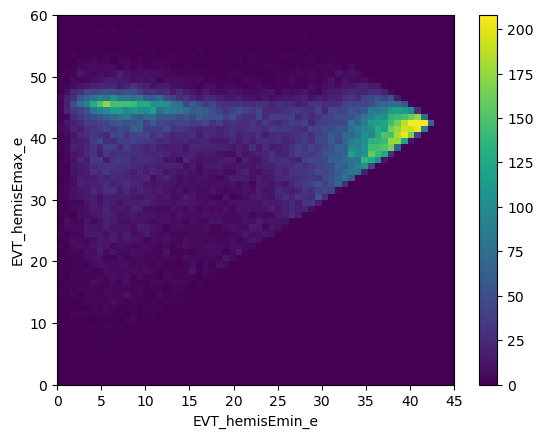

In [85]:
plt.hist2d(values["EVT_hemisEmin_e"], values["EVT_hemisEmax_e"],range=((0,45),(0,60)),bins=60)
plt.xlabel("EVT_hemisEmin_e")
plt.ylabel("EVT_hemisEmax_e")
plt.colorbar()
plt.show()
